In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load cleaned data
df = pd.read_csv("cleaned_bearing_data.csv", parse_dates=["subscription_start", "timestamp_of_fault"])

# Calculate operational life
df["operational_days"] = (df["timestamp_of_fault"] - df["subscription_start"]).dt.days
df = df[df["operational_days"].notna()]


In [2]:
df["context_key"] = (
    df["industry_type"].astype(str) + "|" +
    df["machine_type"].astype(str) + "|" +
    df["rpm_min"].astype(str)
)


In [3]:
# Filter for records with bearing type info
df = df[df['bearing_type_assigned_1'].notna()]
df["bearing_type"] = df["bearing_type_assigned_1"]

# Group and calculate
grouped = df.groupby(["context_key", "bearing_type"]).agg(
    avg_life=("operational_days", "mean"),
    min_life=("operational_days", "min"),
    max_life=("operational_days", "max"),
    count=("operational_days", "count")
).reset_index()

# Filter for reliable results (e.g., ≥ 10 samples)
grouped = grouped[grouped["count"] >= 10]

# Save for app
grouped.to_csv("outputs/q7/bearing_life_by_context.csv", index=False)


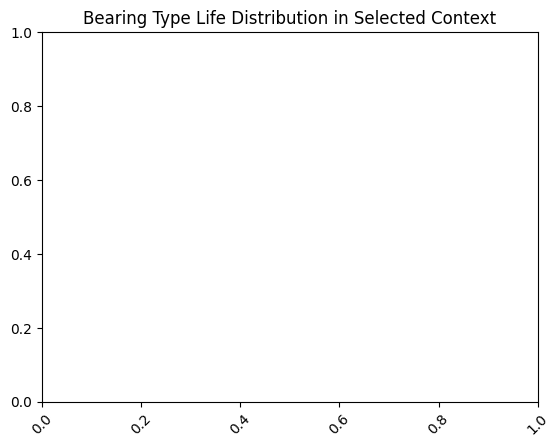

In [4]:
# Example plot
sns.boxplot(data=df[df['context_key'] == "INDUSTRY_1|Gearbox - Bevel Gearbox|1485"],
            x="bearing_type", y="operational_days")
plt.xticks(rotation=45)
plt.title("Bearing Type Life Distribution in Selected Context")
plt.show()
